<a href="https://colab.research.google.com/github/Saint-Sakaro/31_Variant_Belov_PREDPROF/blob/main/homework_1_ridgereg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Машинное обучение
# Задание 1. Ridge-регрессия

Дата выдачи: 07.09.2026

### О задании

Вы научитесь:
 * подготавливать данные для обучения линейных моделей;
 * обучать Ridge-регрессию при помощи модуля scikit-learn;
 * вычислять ошибки на валидационной и тренировочной выборках;
 * проверять модель на переобучение;
 * оценивать качество модели

#### Шаг 1. Скачайте датасет, откройте его и выведите таблицу на экран

In [20]:
!gdown 17G0uMNMh3L20eMcgEwsTuOv75oLvZrnR

Downloading...
From: https://drive.google.com/uc?id=17G0uMNMh3L20eMcgEwsTuOv75oLvZrnR
To: /content/apartment_dataset.csv
100% 4.81k/4.81k [00:00<00:00, 8.86MB/s]


In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [22]:
data = pd.read_csv('apartment_dataset.csv', index_col='apartment id')
data.nunique()

,0
rooms,4
total area,168
floor,25
complex rating,19
price,187


In [23]:
data.describe()

,rooms,total area,floor,complex rating,price
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1.985000,60.436500,13.130000,4.025500,11.156450
std,0.999887,24.680218,7.062755,0.508322,4.276733
min,1.000000,30.100000,1.000000,3.200000,5.130000
25%,1.000000,40.375000,7.000000,3.575000,7.800000
50%,2.000000,54.950000,13.000000,4.000000,10.130000
75%,3.000000,79.325000,19.000000,4.400000,14.177500
max,4.000000,125.500000,25.000000,5.000000,24.500000


<Axes: >

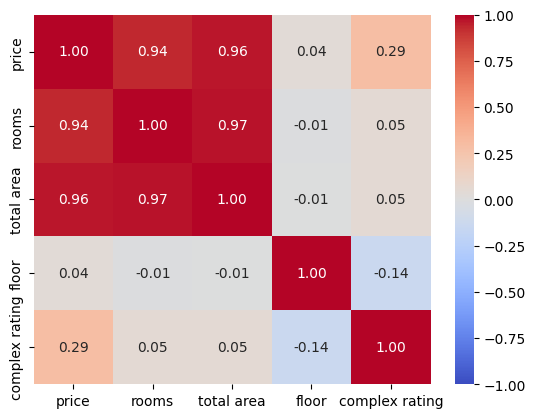

In [24]:
sns.heatmap(data[['price'] + ['rooms', 'total area', 'floor', 'complex rating']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)

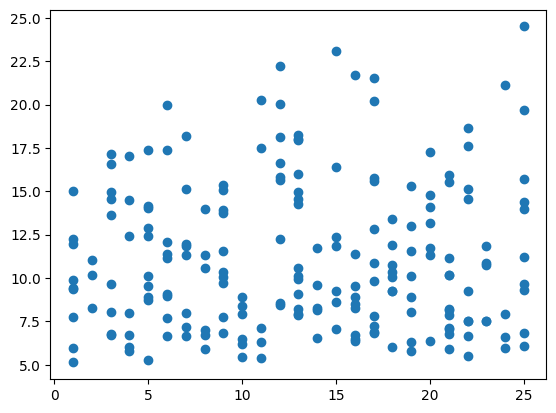

In [25]:
plt.scatter(data['floor'],y=data['price'])

#### Шаг2. Разделите выборку на тренировочную валидационную и тестовую:
* в тренировочной: 100 первых квартир;
* в валидационной: 50 следующих квартир;
* в тестовой: 50 последних квартир.
* в каждой выборке матрица X - это столбцы rooms, total area, floor, complex rating, а y - столбец price.

Названия: X_train, y_train, X_val, y_val, X_test, y_test.

In [26]:
X = data[['rooms', 'total area', 'floor', 'complex rating']]
y = data['price']
X_train = data.loc[:100, 'rooms':'complex rating']
y_train = data.loc[:100, 'price']

X_val= data.loc[101:150, 'rooms':'complex rating']
y_val = data.loc[101:150, 'price']

X_test = data.loc[151:200, 'rooms':'complex rating']
y_test = data.loc[151:200, 'price']



#### Шаг 3. Устанавите sklearn чтобы обучать модель Ridge-регрессии

In [27]:
# Запустите код, чтобы библиотека установилась
!pip install scikit-learn

#### Шаг 4. Обучите модель линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg с ошибкой, которая вычисляется по формуле SSE.

In [28]:
from sklearn.linear_model import Ridge

In [29]:
model = Ridge(alpha=0, solver='sparse_cg') #random_state не нужен т.к. спарс детерменировано начинает с нулей
model.fit(X_train, y_train)

y_pred = model.predict(X_train)
SSE = ((y_pred - y_train) ** 2).sum()
SSE

np.float64(14.397858804243432)

#### Шаг 5. Выведите на экран графики ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок, чтобы отследить их траекторию.

Для этого задания нужно расписать алгоритм обучения вручную, так как функция Ridge в питоне внутри себя эти ошибки не сохраняет.

В самом алгоритме нужно считать и сохранять SSE, MSE, RMSE на каждом шаге итерации для train и для val выборки.

Перед началом алгоритма нужно задать эпсилон - значение ошибки, после которой обучение останавливается, и количество максимальных итераций.

Обучение должно останавливаться тогда, когда выполнен один из двух критериев остановки: либо модуль ошибки меньше эпсилон, либо количество итераций дошло до максимального числа.

* SSE - сумма всех квадратичных отклонений
* MSE - средеее квадратичное отклонение
* RMSE - среднее отклонение предсказания ответа

Подумайте, какие значения для нашего датасета у этих ошибок могут быть допустимыми, чтобы утверждать, что модель обучилась качественно.

После подсчета всех ошибок на всех итерациях нужно вывести на экран три графика:
* график SSE в зависимости от номера итерации: две линии (для train и val)
* график MSE в зависимости от номера итерации: две линии (для train и val)
* график RMSE в зависимости от номера итерации: две линии (для train и val)

In [55]:
X = X_train.values
y = y_train.values

X = np.c_[np.ones(len(X)), X]
w = np.zeros(X.shape[1])
eta = 1e-6
history = []

for i in range(10000): # обычным градиентовым списком без нормализации
  grad = 2 * X.T @ (X @ w - y)
  w = w - eta * grad
  history.append(((X @ w - y) ** 2).sum())
history[-1]

np.float64(87.97192386571815)

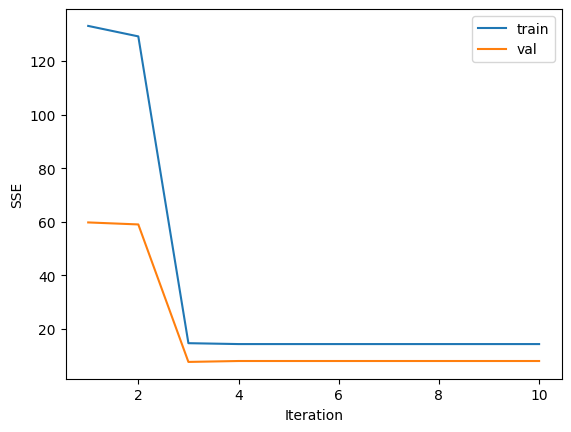

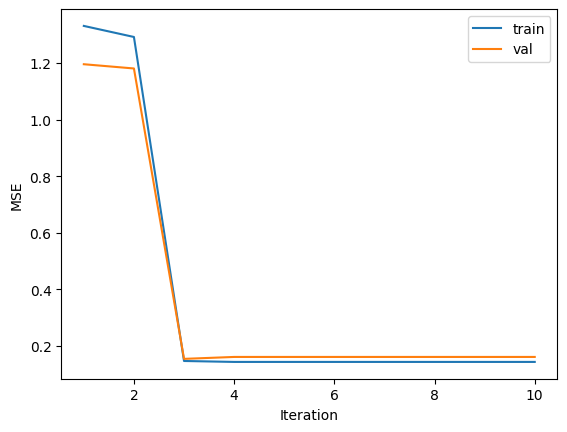

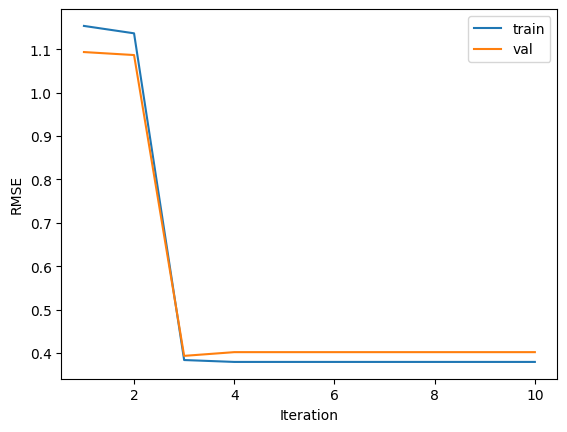

In [63]:
def errors(y_pred, y_true):
  SSE = ((y_true - y_pred) ** 2).sum()
  MSE = SSE / len(y_true)
  RMSE = np.sqrt(MSE)
  return SSE, MSE, RMSE

SSE_train, MSE_train, RMSE_train = [], [], []
SSE_val, MSE_val, RMSE_val = [], [], []

for k in range(1, 11):
  model = Ridge(alpha=0, solver='sparse_cg', max_iter=k)
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_val_pred = model.predict(X_val)

  sse_train, mse_train, rmse_train = errors(y_train_pred, y_train)
  SSE_train.append(sse_train)
  MSE_train.append(mse_train)
  RMSE_train.append(rmse_train)

  sse_val, mse_val, rmse_val = errors(y_val_pred, y_val)
  SSE_val.append(sse_val)
  MSE_val.append(mse_val)
  RMSE_val.append(rmse_val)

iters = range(1,11)
plt.plot(iters, SSE_train, label='train')
plt.plot(iters, SSE_val, label='val')
plt.xlabel('Iteration')
plt.ylabel('SSE')
plt.legend()
plt.show()

plt.plot(iters, MSE_train, label='train')
plt.plot(iters, MSE_val, label='val')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.show()

plt.plot(iters, RMSE_train, label='train')
plt.plot(iters, RMSE_val, label='val')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.legend()
plt.show()

#ИНтересное замечание по поводу разной размерности и почему это плохо для SSE

#### Ответьте на вопрос, какую модель Вы получили: обученную, переобученную или недообученную?

* если на графиках все три ошибки для обеих выборок падают - модель обучилась хорошо
* если на графиках ошибки на train падают, а на val с какого-то момента растут - модель переобучилась (подумайте, что стоит изменить в этом случае)
* если на графиках обе ошибки высокие - модель недообучилась (подумайте, что стоит изменить в этом случае)

#### Шаг 6. Применяем модель на тестовой выборке, чтобы предсказать цены квартир.

1. Найдите y_predict

2. Для каждой квартиры из test выведите на экран:
* id квартиры
* её предсказанную цену
* её настоящую цену
* разницу между предсказанной и настоящей ценой (чтобы оценить насколько хорошо Ваша модель предсказывает цены)

3. сохранить получившуюся таблицу

P.S. В итоговой таблице все столбцы должны быть подписаны.

In [69]:
model = Ridge(alpha=0, solver='sparse_cg')
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

data_res = pd.DataFrame({
    'ID квартиры' : X_test.index,
    'Предсказанная цена' : y_predict,
    'Реальная цена' : y_test,
    'Разница между ценами' : y_predict - y_test,
})

data_res = data_res.reset_index(drop=True)
data_res

,ID квартиры,Предсказанная цена,Реальная цена,Разница между ценами
0,151,20.887104,21.54,-0.652896
1,152,9.969090,9.73,0.239090
2,153,7.670861,7.74,-0.069139
3,154,10.469829,10.15,0.319829
4,155,17.601324,17.27,0.331324
5,156,8.995066,8.23,0.765066
6,157,8.356086,8.52,-0.163914
7,158,14.702205,14.95,-0.247795
8,159,8.452857,8.16,0.292857
9,160,14.878951,14.95,-0.071049


In [70]:
data_res.to_csv('prediction.csv', index=False)

### Поздравляю! Вы обучили модель и уже сделали первый шаг в машинном обучении! Молодцы!